<a href="https://colab.research.google.com/github/GnanaDeepika786/Email_Spam_Detection/blob/main/Email_spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("spam.csv", encoding='latin-1')

# Display first 5 rows
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
# Check dataset information
print(df.shape)

# Display column names
print(df.columns)

# Check for missing values
print(df.isnull().sum())

(5572, 5)
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


In [ ]:
# Remove unnecessary columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'message']

# Display first 5 rows
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Convert labels into numbers
# ham = 0, spam = 1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Display first 5 rows
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Input (messages)
X = df['message']

# Output (0 = ham, 1 = spam)
y = df['label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert text into numbers
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

# Train the model
model = MultinomialNB()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Show accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9623318385650225


In [ ]:
# Enter your own message here
message = ["Congratulations! You have won a FREE iPhone. Click here to claim your prize."]

# Convert the message into numbers
message_vector = vectorizer.transform(message)

# Predict
prediction = model.predict(message_vector)

# Display result
if prediction[0] == 1:
    print("Spam")
else:
    print("Not Spam")

Spam


In [ ]:
# Enter your own message here
message = ["Hi Meghana, are you coming to college tomorrow?"]

# Convert the message into numbers
message_vector = vectorizer.transform(message)

# Predict
prediction = model.predict(message_vector)

# Display result
if prediction[0] == 1:
    print("Spam")
else:
    print("Not Spam")

Not Spam


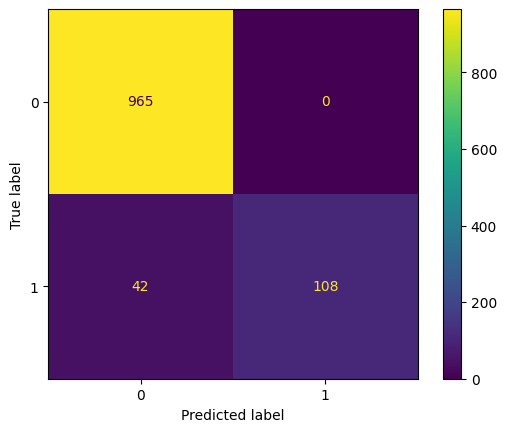

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



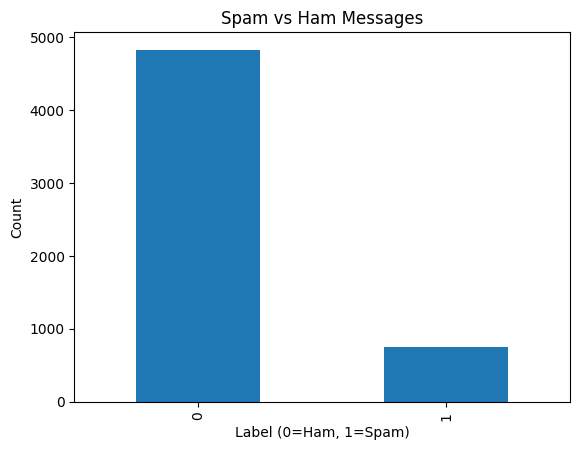

In [ ]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Messages")
plt.xlabel("Label (0=Ham, 1=Spam)")
plt.ylabel("Count")
plt.show()

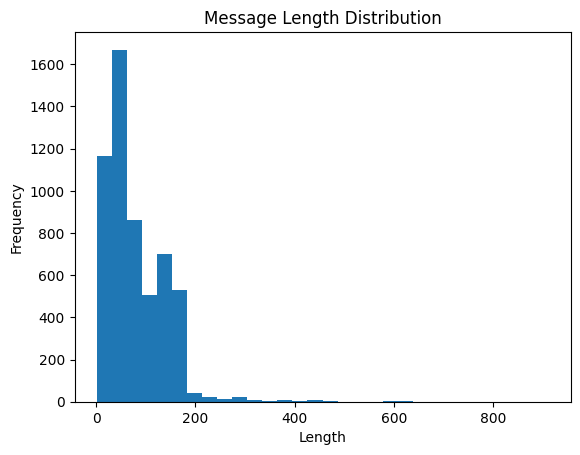

In [ ]:
df['length'] = df['message'].apply(len)

plt.hist(df['length'], bins=30)
plt.title("Message Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

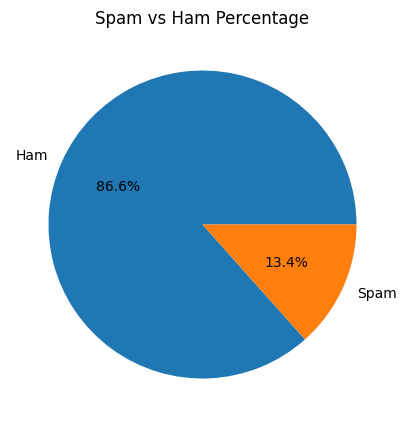

In [ ]:
plt.figure(figsize=(5,5))

df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Ham','Spam']
)

plt.title("Spam vs Ham Percentage")
plt.ylabel("")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression()

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

from sklearn.metrics import accuracy_score

print("Baseline Model Accuracy:", accuracy_score(y_test, baseline_pred))

Baseline Model Accuracy: 0.967713004484305
